# 📊 Shopper Spectrum: Exploratory Data Analysis (EDA)
This notebook performs the Exploratory Data Analysis (EDA) for the **Shopper Spectrum** project. We will explore the dataset, clean the raw retail transaction data, and extract behavioral insights such as:
* Transaction volumes and revenues across different countries
* Top-selling products by quantity and revenue
* Sales trends over time (monthly, daily, hourly)
* Distributions of transactional attributes (Quantity, UnitPrice, and Order Value)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set visualization parameters
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Dataset
We will load the raw dataset from `../data/online_retail.csv` and inspect its shape, columns, and data types.

In [2]:
# Load data
csv_path = '../data/online_retail.csv'
df = pd.read_csv(csv_path)
print(f"Raw dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.\n")
df.info()

Raw dataset contains 541,909 rows and 8 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [3]:
# Inspect first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


### Inspect Missing Values & Anomalies
Let's see how many missing values exist in each column.

In [4]:
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_percentage.round(2)})
missing_df

,Missing Count,Percentage (%)
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


## 2. Data Preprocessing & Cleaning
To ensure the quality of our clustering and recommendation models, we apply the following cleaning steps:
1. **Remove rows with missing CustomerID:** Since we need CustomerID to perform customer-level RFM analysis and segmentation.
2. **Exclude cancelled invoices:** Invoices starting with 'C' represent cancellations/refunds.
3. **Remove negative or zero quantities and unit prices:** These represents returns, corrections, or free items that distort revenue calculations.
4. **Convert CustomerID to string** and format **InvoiceDate** as datetime.
5. **Create TotalAmount** feature: `Quantity * UnitPrice`.

In [5]:
# 1. Drop rows with null CustomerID
clean_df = df.dropna(subset=['CustomerID']).copy()

# 2. Remove cancelled invoices (InvoiceNo starting with 'C')
clean_df = clean_df[~clean_df['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Remove non-positive quantities and prices
clean_df = clean_df[(clean_df['Quantity'] > 0) & (clean_df['UnitPrice'] > 0)]

# 4. Format columns
clean_df['CustomerID'] = clean_df['CustomerID'].astype(int).astype(str)
clean_df['InvoiceDate'] = pd.to_datetime(clean_df['InvoiceDate'])

# 5. Calculate Total Amount spent per transaction item
clean_df['TotalAmount'] = clean_df['Quantity'] * clean_df['UnitPrice']

print(f"Post-Cleaning shape: {clean_df.shape[0]:,} rows (filtered {(df.shape[0]-clean_df.shape[0]):,} rows)")
print(f"Unique Customers: {clean_df['CustomerID'].nunique():,}")
print(f"Unique Products: {clean_df['StockCode'].nunique():,}")

Post-Cleaning shape: 397,884 rows (filtered 144,025 rows)
Unique Customers: 4,338
Unique Products: 3,665


## 3. Geographical Distribution Analysis
Let's see which countries have the highest transaction volumes and total revenue.

In [6]:
# Group transactions and revenue by country
country_stats = clean_df.groupby('Country').agg(
    TransactionCount=('InvoiceNo', 'count'),
    TotalRevenue=('TotalAmount', 'sum')
).sort_values(by='TotalRevenue', ascending=False).reset_index()

# Add percentage columns
country_stats['TransactionShare (%)'] = (country_stats['TransactionCount'] / country_stats['TransactionCount'].sum() * 100).round(2)
country_stats['RevenueShare (%)'] = (country_stats['TotalRevenue'] / country_stats['TotalRevenue'].sum() * 100).round(2)

print("Top 10 Countries by Revenue:")
display(country_stats.head(10))

Top 10 Countries by Revenue:


,Country,TransactionCount,TotalRevenue,TransactionShare (%),RevenueShare (%)
0,United Kingdom,354321,7308391.554,89.05,82.01
1,Netherlands,2359,285446.340,0.59,3.20
2,EIRE,7236,265545.900,1.82,2.98
3,Germany,9040,228867.140,2.27,2.57
4,France,8341,209024.050,2.10,2.35
5,Australia,1182,138521.310,0.30,1.55
6,Spain,2484,61577.110,0.62,0.69
7,Switzerland,1841,56443.950,0.46,0.63
8,Belgium,2031,41196.340,0.51,0.46
9,Sweden,451,38378.330,0.11,0.43


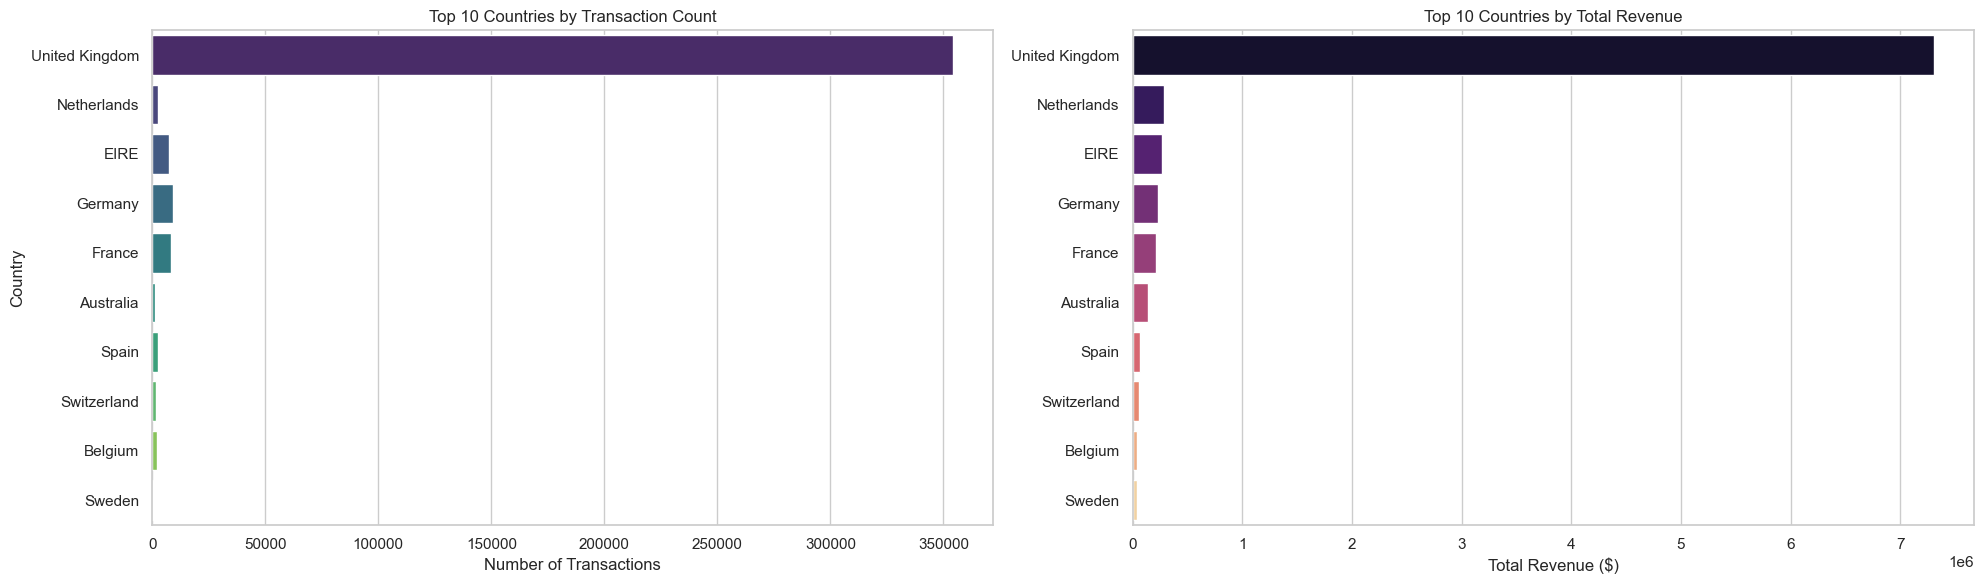

In [7]:
# Plot transaction volumes and revenues side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=country_stats.head(10), x='TransactionCount', y='Country', palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Countries by Transaction Count')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Country')

sns.barplot(data=country_stats.head(10), x='TotalRevenue', y='Country', palette='magma', ax=axes[1])
axes[1].set_title('Top 10 Countries by Total Revenue')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 4. Product Sales Insights
Identify the top-selling products by total Quantity sold and total Revenue generated.

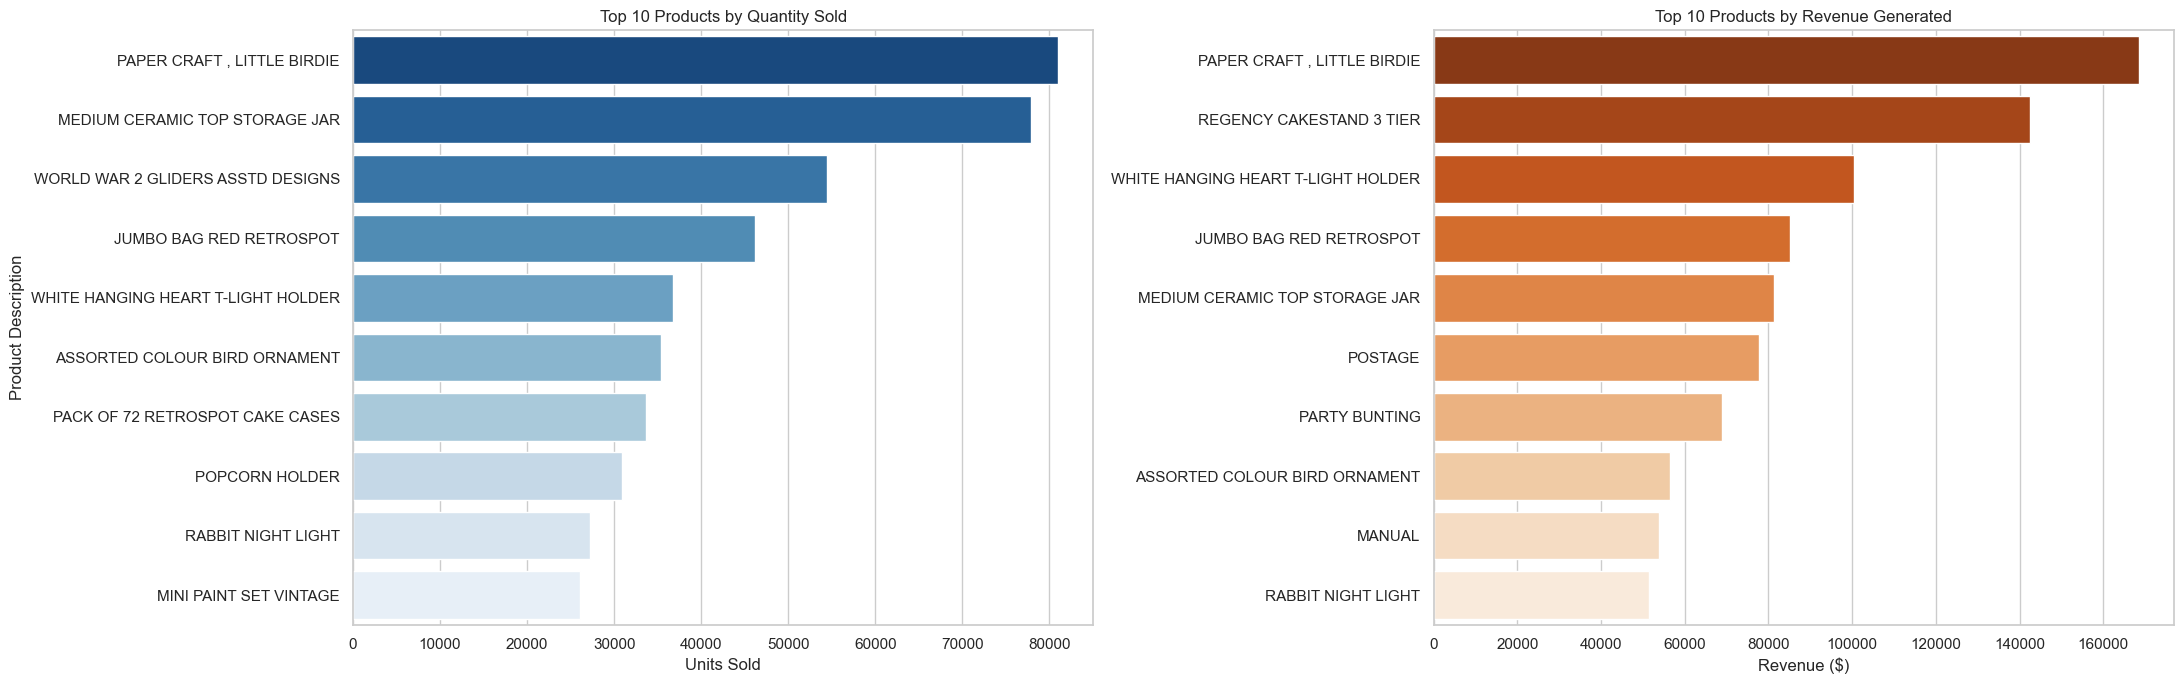

In [8]:
# Clean descriptions (trim whitespace and make uppercase)
clean_df['Description'] = clean_df['Description'].str.strip().str.upper()

# Top products by quantity sold
top_qty = clean_df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).reset_index()

# Top products by revenue
top_revenue = clean_df.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

sns.barplot(data=top_qty, x='Quantity', y='Description', palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 Products by Quantity Sold')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Product Description')

sns.barplot(data=top_revenue, x='TotalAmount', y='Description', palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top 10 Products by Revenue Generated')
axes[1].set_xlabel('Revenue ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Temporal Sales & Transaction Patterns
Let's extract and plot transaction trends across months, days of the week, and hours of the day to discover when customers are most active.

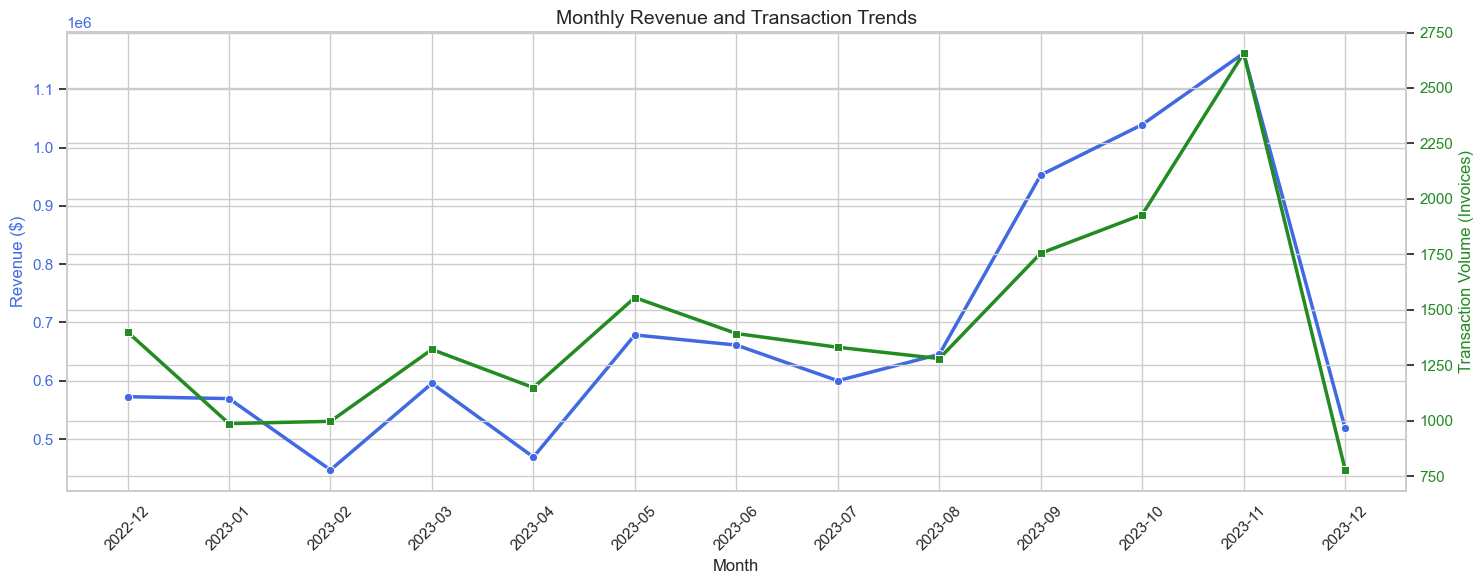

In [9]:
# Extract monthly and weekly variables
clean_df['Month'] = clean_df['InvoiceDate'].dt.to_period('M').astype(str)
clean_df['DayOfWeek'] = clean_df['InvoiceDate'].dt.day_name()
clean_df['Hour'] = clean_df['InvoiceDate'].dt.hour

# Aggregate monthly revenue and invoice counts
monthly_data = clean_df.groupby('Month').agg(
    Revenue=('TotalAmount', 'sum'),
    Invoices=('InvoiceNo', 'nunique')
).reset_index()

fig, ax1 = plt.subplots(figsize=(15, 6))
sns.lineplot(data=monthly_data, x='Month', y='Revenue', marker='o', color='royalblue', linewidth=2.5, ax=ax1)
ax1.set_title('Monthly Revenue and Transaction Trends', fontsize=14)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Revenue ($)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')
plt.xticks(rotation=45)

ax2 = ax1.twinx()
sns.lineplot(data=monthly_data, x='Month', y='Invoices', marker='s', color='forestgreen', linewidth=2.5, ax=ax2)
ax2.set_ylabel('Transaction Volume (Invoices)', color='forestgreen', fontsize=12)
ax2.tick_params(axis='y', labelcolor='forestgreen')

plt.tight_layout()
plt.show()

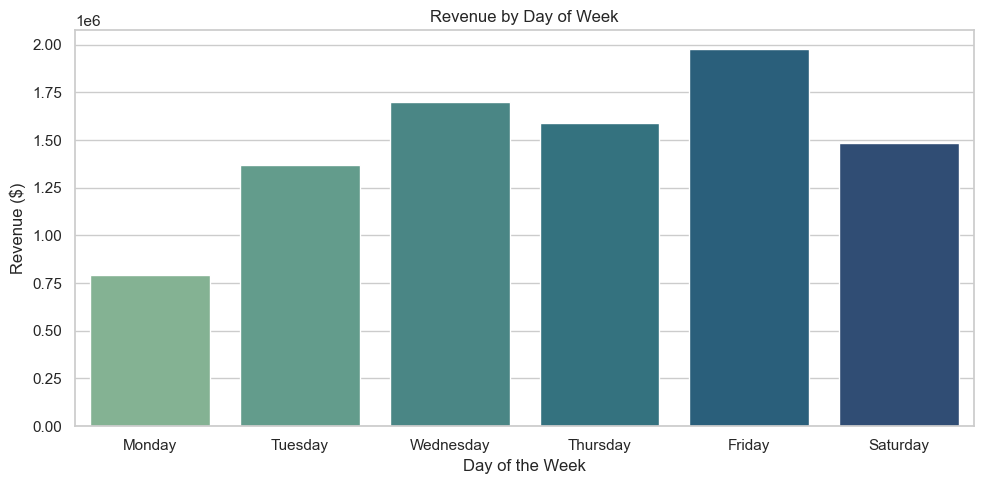

In [10]:
# Sales by Day of the Week
# Note: Sunday has no transactions/data in this retail dataset
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
weekly_revenue = clean_df.groupby('DayOfWeek')['TotalAmount'].sum().reindex(day_order).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=weekly_revenue, x='DayOfWeek', y='TotalAmount', palette='crest')
plt.title('Revenue by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

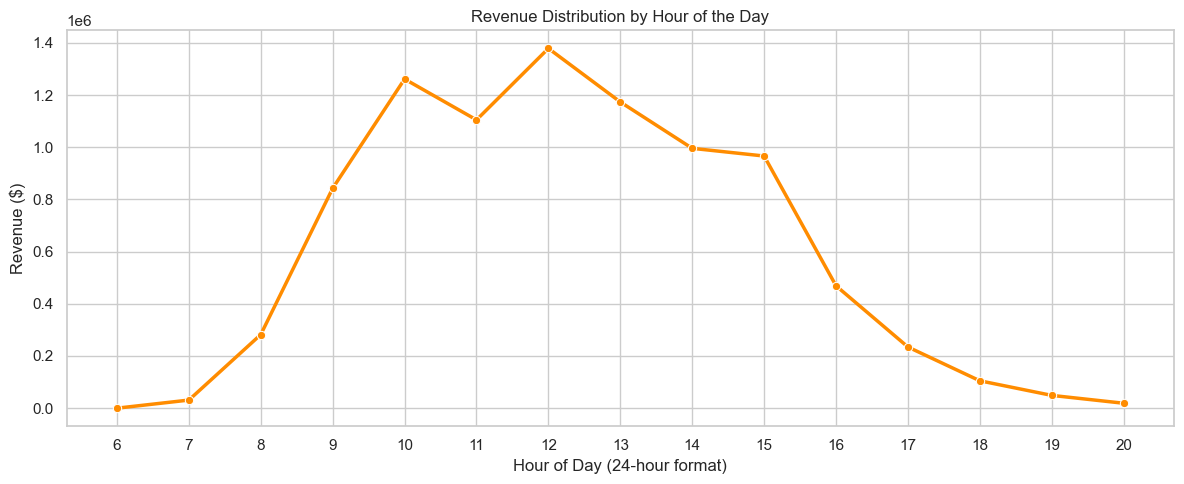

In [11]:
# Sales by Hour of Day
hourly_revenue = clean_df.groupby('Hour')['TotalAmount'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_revenue, x='Hour', y='TotalAmount', marker='o', color='darkorange', linewidth=2.5)
plt.title('Revenue Distribution by Hour of the Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Revenue ($)')
plt.xticks(range(6, 21))
plt.tight_layout()
plt.show()

## 6. Distributonal Characteristics of Transactions
We inspect the distributions of unit price, quantity, and total transaction values to spot outliers and skewness.

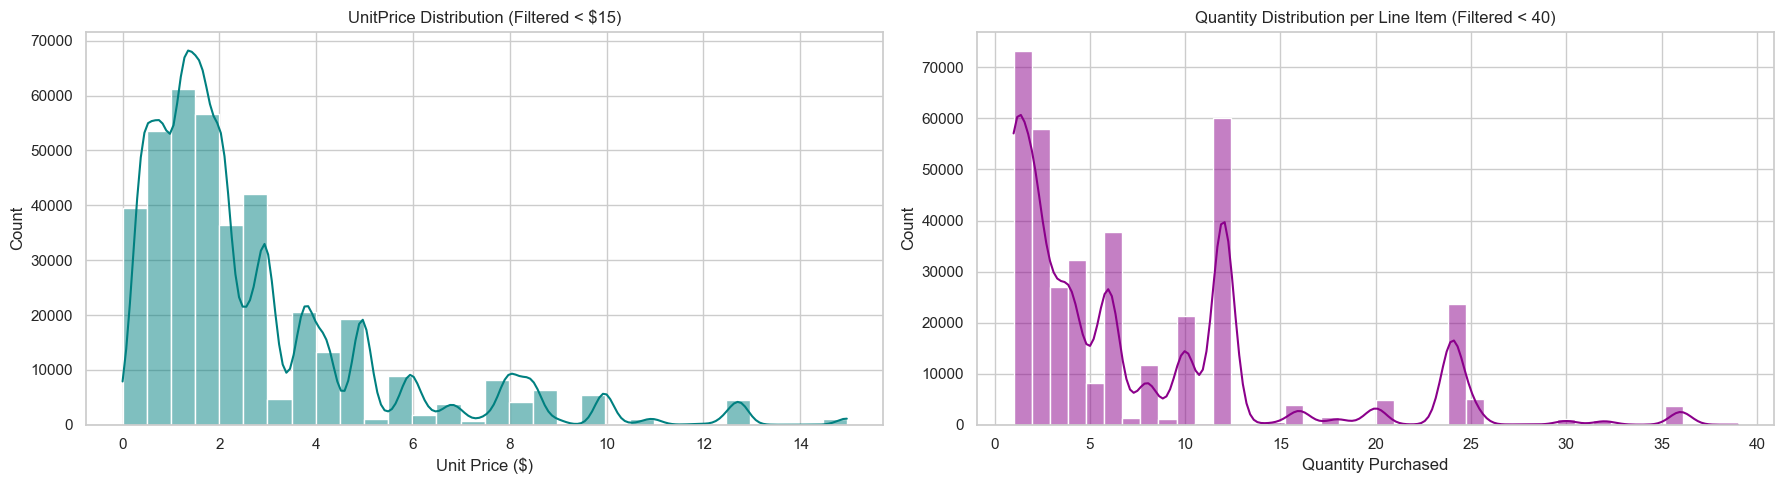

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# UnitPrice Distribution
sns.histplot(clean_df[clean_df['UnitPrice'] < 15]['UnitPrice'], bins=30, kde=True, color='teal', ax=axes[0])
axes[0].set_title('UnitPrice Distribution (Filtered < $15)')
axes[0].set_xlabel('Unit Price ($)')

# Quantity Distribution
sns.histplot(clean_df[clean_df['Quantity'] < 40]['Quantity'], bins=40, kde=True, color='darkmagenta', ax=axes[1])
axes[1].set_title('Quantity Distribution per Line Item (Filtered < 40)')
axes[1].set_xlabel('Quantity Purchased')

plt.tight_layout()
plt.show()

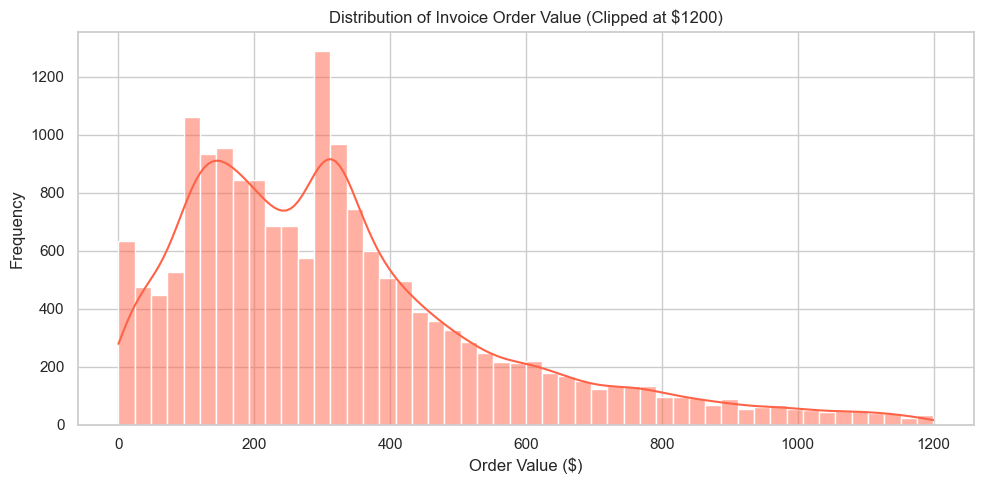

In [13]:
# Invoice value distribution
invoice_totals = clean_df.groupby('InvoiceNo')['TotalAmount'].sum()
plt.figure(figsize=(10, 5))
sns.histplot(invoice_totals[invoice_totals < 1200], bins=50, kde=True, color='tomato')
plt.title('Distribution of Invoice Order Value (Clipped at $1200)')
plt.xlabel('Order Value ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()